# 순환 신경망(RNN)

지금까지 살펴본 신경망은 **피드포워드(feed forward)(앞먹임)** 라는 유형의 신경망   
피드포워드란 흐름이 단방향인 신경망   
다시 말해, 입력 신호가 다음 층(중간층)으로 전달되고, 그 신호를 받은 층은 그다음 층으로 전달하고, 다시 다음 층으로... 식으로 한 방향으로만 신호가 전달됨   

피드포워드 신경망은 구성이 단순하여 구조를 이해하기 쉽고, 그래서 많은 문제에 응용할 수 있음   
그러나 커다란 단점이 바로 시계열 데이터를 잘 다루지 못한다는 것   
더 정확하게 말하면, 단순한 피드포워드 신경망에서는 시계열 데이터의 성질(패턴)을 충분히 학습할 수 없음   
그래서 **순환 신경망(Recurrent Neural Network)(RNN)** 이 등장   

이번 장에서는 피드포워드 신경망의 문제점을 지적하고, RNN이 그 문제를 훌륭하게 해결할 수 있음을 설명   
또한 RNN의 구조를 차분히 시간을 들여 설명하면서, 파이썬으로 구현도 해볼 것

## 확률과 언어 모델

이번 절에서는 RNN 이야기를 시작하기 위한 준비 과정으로, 먼저 앞 장의 word2vec을 복습   
그런 다음 자연어에 관한 현상을 '확률'을 사용해 기술하고, 마지막에는 언어를 확률로 다루는 '언어 모델'에 대해 설명

### word2vec을 확률 관점에서 바라보다

그럼 word2vec의 CBOW 모델부터 복습   
여기에서는 w1, w2, …, wT라는 단어열로 표현되는 말뭉치를 생각해볼 것   
그리고 t번째 단어를 '타깃'으로, 그 전후 단어(t-1번째와 t+1번째)를 '맥락'으로 취급

> 이 책에서 타깃은 '중앙 단어'를, 맥락은 타깃의 '주변 단어'를 가리킴   

이때 CBOW 모델은 아래 그림처럼 맥락 wt-1과 wt+1로부터 타깃 wt를 추측하는 일을 수행   
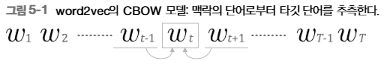   

그럼 wt-1과 wt+1이 주어졌을 때 타깃이 wt가 될 확률을 수식으로 나타내보면   
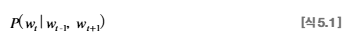   
- CBOW 모델은 이 식의 사후 확률을 모델링함
- 이 사후 확률은 'wt-1과 wt+1이 주어졌을 때 wt가 일어날 확률'을 뜻함
- 이것이 윈도우 크기가 1일 때의 CBOW 모델   

그런데 지금까지는 맥락을 항상 좌우 대칭으로 생각해왔음   
이번에는 맥락을 왼쪽 윈도우만으로 한정해봄   
예컨대 아래 그림과 같은 경우를 생각해보면   
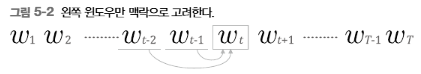   
- 그림처럼 왼쪽 두 단어만을 맥락으로 생각
- 그러면 CBOW 모델이 출력할 확률은 아래 식처럼 됨   
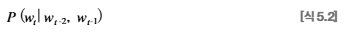   

> word2vec에서 맥락의 윈도우 크기는 하이퍼파라미터   
> 임의의 값으로 설정할 수 있다는 뜻   
> 이번 예에서는 윈도우 크기를 '왼쪽 2 단어, 오른쪽 0 단어'라는 좌우 비대칭으로 설정   
> 이렇게 설정한 이유는 나중에 설명하는 '언어 모델'에서 이야기함   

위 식의 표기를 사용하면, CBOW 모델이 다루는 손실 함수를 아래 식처럼 쓸 수 있음   
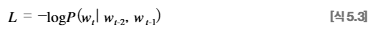   
- 이 식은 교차 엔트로피 오차에 의해 유도한 결과
- CBOW 모델의 학습으로 수행하는 일은 이 식의 손실 함수(정확히는 말뭉치 전체의 손실 함수의 총합)를 최소화하는 가중치 매개변수를 찾는 것
- 이러한 가중치 매개변수가 발견되면 CBOW 모델은 맥락으로부터 타깃을 더 정확하게 추측할 수 있게 됨   

이처럼 CBOW 모델을 학습시키는 본래 목적은 맥락으로부터 타깃을 정확하게 추측하는 것   
이 목적을 위해 학습을 진행하면, (그 부산물로) 단어의 의미가 인코딩된 '단어의 분산 표현'을 얻을 수 있음   

그럼 CBOW 모델의 본래 목적인 '맥락으로부터 타깃을 추측하는 것'은 어디에 이용할 수 있을지   
위에 식의 확률 P(wt|wt-2, wt-1)은 실용적인 쓰임이 있는지   
여기서 '언어 모델'이 등장

### 언어 모델

**언어 모델(Language Model)** 은 단어 나열에 확률을 부여함   
특정한 단어의 시퀀스에 대해서, 그 시퀀스가 일어날 가능성이 어느 정도인지(얼마나 자연스러운 단어 순서인지)를 확률로 평가하는 것   
예컨대 "you say goodbye"라는 단어 시퀀스에는 높은 확률(예: 0.092)을 출력하고, "you say good die"에는 낮은 확률(예: 0.0000000000032)을 출력하는 것이 일종의 언어 모델   

이 언어 모델은 다양하게 응용할 수 있음   
기계 번역과 음성 인식이 대표적인 예   
예를 들어 음성 인식 시스템의 경우, 사람의 음성으로부터 몇 개의 문장을 후보로 생성할 것   
그런 다음 언어 모델을 사용하여 후보 문장이 '문장으로써 자연스러운지'를 기준으로 순서를 매길 수 있음   

또한 언어 모델은 새로운 문장을 생성하는 용도로도 이용할 수 있음   
왜냐하면 언어 모델은 단어 순서의 자연스러움을 확률적으로 평가할 수 있으므로, 그 확률분포에 따라 다음으로 적합한 단어를 '자아낼'(샘플링) 수 있기 때문   

그러면 언어 모델을 수식으로 설명   
w1, ..., wm이라는 m개 단어로 된 문장을 생각해보면   
이때 단어가 w1, ..., wm이라는 순서로 출현할 확률을 P(w1, …, wm)으로 나타냄   
이 확률은 여러 사건이 동시에 일어날 확률이므로 동시 확률이라고 함   

이 동시 확률 P(w1, ..., wm)은 사후 확률을 사용하여 다음과 같이 분해하여 쓸 수 있음   
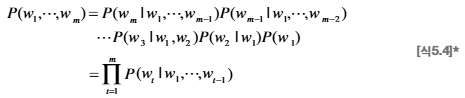   
- 식의 기호는 모든 원소를 곱하는 '총곱'을 뜻함(총합을 뜻하는 ∑(시그마)와 구분)
- 식에서 알 수 있듯, 동시 확률은 사후 확률의 총곱으로 나타낼 수 있음
- 식의 결과는 확률의 곱셈정리로부터 유도할 수 있음
- 확률의 곱셈정리는 다음 식으로 표현됨   
   
- 식의 곱셈정리는 확률론에서 가장 중요한 정리
- 이 정리가 의미하는 바는 'A와 B가 모두 일어날 확률 P(A, B)'는 'B가 일어날 확률 P(B)'와 'B가 일어난 후 A가 일어날 확률 P(A|B)'를 곱한 값과 같다는 것   

> 확률 P(A, B)를 P(A, B) = P(B|A)P(A)처럼 분해할 수도 있음   
> 즉, A와 B 중 어느 것을 사후 확률의 조건으로 할지에 따라 P(A, B) = P(B|A)P(A) 와 P(A, B) = P(A|B)P(B)의 2가지 표시 방법이 존재   

이 곱셈정리를 사용하면 m개 단어의 동시 확률 P(w1, ..., wm)을 사후 확률로 나타낼 수 있음   
이때 수행하는 식 변형을 알기 쉽게 나타내면 다음과 같음   
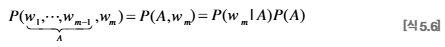   
- 여기에서는 w1, ..., wm-1을 하나로 모아 기호 A로 나타냄
- 그러면 곱셈정리를 수행하여 아래 식이 유도됨
- 이번에도 A(w1, ..., wm-1)에 대해서 다시 같은 식 변형을 수행   
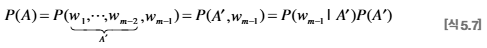   
- 이처럼 단어 시퀀스를 하나씩 줄여가면서 매번 사후 확률로 분해해 감
- 그리고 같은 과정을 반복하여 최종 식을 이끌 수 있음   

최종 식에서 알 수 있듯이 목적으로 하는 동시 확률 P(w1, ..., wm)은 사후 확률의 총곱인 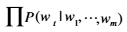으로 대표될 수 있음   
여기에서 주목할 것은 이 사후 확률은 타깃 단어보다 왼쪽에 있는 모든 단어를 맥락(조건)으로 했을 때의 확률이라는 것   
그림으로 보면   
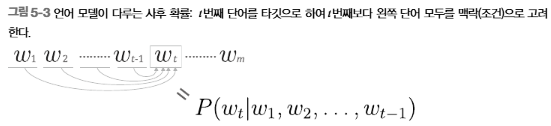   

지금까지의 이야기를 정리하면, 목표는 P(wt|w1, ..., wt-1)이라는 확률을 얻는 것   
이 확률을 계산할 수 있다면 언어 모델의 동시 확률 P(w1, ..., wm)을 구할 수 있음   

> P(wt|w1, ..., wt-1)을 나타내는 모델은 **조건부 언어 모델(Conditional Language Model)** 이라고 함   
> 한편, P(wt|w1, …, wt-1)을 나타내는 모델을 가리켜, 그것을 '언어 모델'이라 하는 경우도 많이 볼 수 있음

### CBOW 모델을 언어 모델로?

그렇다면 word2vec의 CBOW 모델을 (억지로) 언어 모델에 적용하려면 어떻게 하는지   
이는 맥락의 크기를 특정 값으로 한정하여 근사적으로 나타낼 수 있음   
수식으로는 다음과 같음   
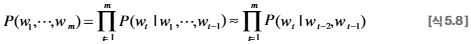   
- 여기에서는 맥락을 왼쪽 2개의 단어로 한정
- 그러면 CBOW 모델에 따라(CBOW 모델의 사후 확률에 따라) 근사적으로 나타낼 수 있음   

> 머신러닝이나 통계학에서는 **마르코프 연쇄(Markov Chain)** 또는 **마르코프 모델(Markov Model)** 이라는 말을 자주 듣을 수 있음   
> 마르코프 연쇄란 미래의 상태가 현재 상태에만 의존해 결정되는 것   
> 또한 이 사상의 확률이 '그 직전' N개의 사건에만 의존할 때, 이를 'N층 마르코프 연쇄'라고 함   
> 이번 예는 직전 2개의 단어에만 의존해 다음 단어가 정해지는 모델이므로 '2층 마르코프 연쇄'라고 부를 수 있음   

위 식에서는 맥락으로 2개의 단어를 이용하는 예를 나타냈지만, 이 맥락의 크기는 임의 길이로 설정할 수 있음(예컨대 5나 10 등)   
그러나 임의 길이로 설정할 수 있다고 해도, 결국 특정 길이로 '고정'됨   
예를 들어 왼쪽 10개의 단어를 맥락으로 CBOW 모델을 만든다고 하면, 그 맥락보다 더 왼쪽에 있는 단어의 정보는 무시됨   
이것이 문제가 될 때가 있는데, 아래 그림이 그 예시   
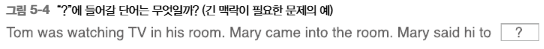   
- 그림의 문제에서 "Tom이 방에서 TV를 보고 있었고, Mary가 그 방에 들어왔다"고 함
- 이 문맥(맥락)을 고려하면 "Mary가 Tom(혹은 he)에게 인사를 건넸다"가 정답
- 이 문제에서 정답을 구하려면 예문의 '?'로부터 18번째나 앞에 나오는 "Tom"을 기억해야 함
- 만약 CBOW 모델의 맥락이 10개까지였다면 이 문제에 제대로 답할 수 없을 것   

그럼 CBOW 모델의 맥락 크기를 20이나 30까지 키우면 문제가 해결되는지   
물론 CBOW 모델의 맥락 크기는 얼마든지 키울 수 있음   
그러나 CBOW 모델에서는 맥락 안의 단어 순서가 무시된다는 한계가 있음   

> CBOW란 continuous bag-of-words의 약어   
> bag-of-words란 '가방 안의 단어'를 뜻하는데, 여기에는 가방 속의 단어 '순서'는 무시된다는 뜻도 내포함('순서'대신 '분포'를 이용함)   

맥락의 단어 순서가 무시되는 문제의 구체적인 예를 하나 보면   
예컨대 맥락으로 2개의 단어를 다루는 경우, CBOW 모델에서는 이 2개의 단어 벡터의 '합'이 은닉층에 옴(아래 그림의 왼쪽처럼)   
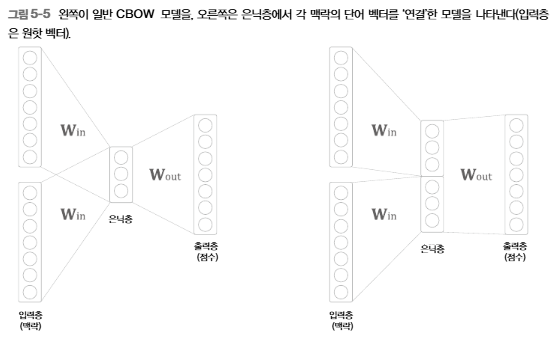   
- 그림의 왼쪽 그림과 같이 CBOW 모델의 은닉층에서는 단어 벡터들이 더해지므로 맥락의 단어 순서는 무시됨
- 예컨대 (you, say)와 (say, you)라는 맥락을 똑같이 취급함
- 이상적으로는 맥락의 단어 순서도 고려한 모델이 바람직
- 이를 위해 그림의 오른쪽처럼 맥락의 단어 벡터를 은닉층에서 **연결(concatenate)** 하는 방식을 생각할 수 있음
- 실제, 신경 확률론적 언어 모델(Neural Probabilistic Language Model)에서 제안한 모델은 이 방식을 취함
- 그러나 연결하는 방식을 취하면 맥락의 크기에 비례해 가중치 매개변수도 늘어나게 됨 - 좋지 않은 현상   

이 문제를 해결하는 것이 순환 신경망(RNN)   
RNN은 맥락이 아무리 길더라도 그 맥락의 정보를 기억하는 메커니즘을 갖추고 있음   
그래서 RNN을 사용하면 아무리 긴 시계열 데이터에라도 대응할 수 있음   

> word2vec은 단어의 분산 표현을 얻을 목적으로 고안된 기법   
> 따라서 이를 언어 모델로 사용하는 경우는 (보통은) 잘 없음   
> 여기에서는 RNN의 특징을 끌어내기 위해 word2vec의 CBOW 모델을 억지로 언어 모델에 적용해본 것   
> 그리고 word2vec은 2013년에, RNN을 이용한 언어 모델은 2010년에 토마스 미콜로프가 이끄는 연구팀에 의해 각각 제안되었음   
> 이들이 설명한 연구 배경에 따르면, RNN을 이용한 언어 모델에서도 단어의 분산 표현을 얻을 수 있지만,   
> 어휘 수 증가에 따른 대응이나 단어의 분산 표현의 '질' 개선을 위해 word2vec을 제안했다고 함

## RNN이란

RNN(Recurrent Neural Network)의 'Recurrent'는 라틴어에서 온 말로, '몇 번이나 반복해서 일어나는 일'을 뜻함   
우리말로는 '재발한다', '주기적으로 일어난다', '순환한다' 등으로 번역됨   
그래서 RNN을 직역하면 '순화하는 신경망'이 되는 것   
이번 절에서는 이 '순환한다'는 말의 의미를 살펴봄   

> Recurrent Neural Network는 우리말로 '순환 신경망'으로 번역함   
> 한편, Recursive Neural Network(재귀 신경망)라는 신경망도 있음   
> 이는 주로 트리 구조의 데이터를 처리하기 위한 신경망으로, 순환 신경망과는 다른 것

### 순환하는 신경망

'순환한다'는 '반복해서 되돌아감'을 의미   
어느 한 지점에서 시작한 것이, 시간을 지나 다시 원래 장소로 돌아오는 것, 그리고 이 과정을 반복하는 것이 바로 '순환'   
여기서 하나 주목할 사실은, 순환하기 위해서는 '닫힌 경로'가 필요하다는 것   

'닫힌 경로' 혹은 '순환하는 경로'가 존재해야 데이터가 같은 장소를 반복해 왕래할 수 있음   
그리고 데이터가 순환하면서 정보가 끊임없이 갱신되게 됨   

> 비유하자면, 혈액은 우리 체내를 순환함   
> 지금 흐르는 혈액은 어제부터 계속해서 흐르던 혈액   
> 나아가 1주일 전부터, 1개월 전부터, 1년 전부터, 그리고 생명을 얻은 그 순간부터 계속해 흘러왔음   
> 그리고 체내를 순환하며 과거로부터 현재로 끊임없이 '갱신'됨   

RNN의 특징은 순환하는 경로(닫힌 경로)가 있다는 것   
이 순환 경로를 따라 데이터는 끊임없이 순환할 수 있음   
그리고 데이터가 순환되기 때문에 과거의 정보를 기억하는 동시에 최신 데이터로 갱신될 수 있는 것   

그럼 RNN을 구체적으로 살펴보면   
여기에서는 RNN에 이용되는 계층을 'RNN 계층'이라고 부름   
RNN 계층은 아래 그림처럼 그릴 수 있음   
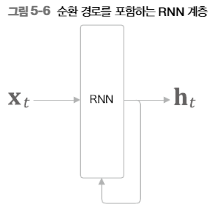   
- 그림처럼 RNN 계층은 순환하는 경로를 포함
- 이 순환 경로를 따라 데이터를 계층 안에서 순환시킬 수 있음
- 또한 그림에서는 xt를 입력받는데, t는 시각을 뜻함
- 이는 시계열 데이터 (x0, x1, ..., xt, ...)가 RNN 계층에 입력됨을 표현한 것
- 그리고 그 입력에 대응하여 (h0, h1, ..., ht, ...)가 출력됨
- 또한, 각 시각에 입력되는 xt는 벡터라고 가정함
- 문장(단어 순서)을 다루는 경우를 예로 든다면 각 단어의 분산 표현(단어 벡터)이 xt가 되며, 이 분산 표현이 순서대로 하나씩 RNN 계층에 입력되는 것   

> 그림을 잘 보면 출력이 2개로 분기하고 있음을 알 수 있음   
> 여기서 말하는 '분기'란 같은 것이 복제되어 분기함을 의미   
> 그리고 이렇게 분기된 출력 중 하나가 자기 자신에 입력됨(즉, 순환함)   

이어서 그림의 순환 구조를 자세히 살펴볼 차례이지만, 그전에 RNN 계층을 그리는 방식을 다음과 같이 변경하고자 함   
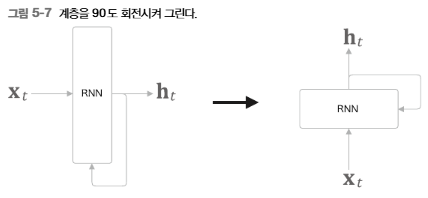   
- 그림에서 보듯, 지금까지는 계층을 그릴 때 데이터가 왼쪽에서 오른쪽으로 흐르는 형태로 그렸음
- 그러나 지금부터는 지면 관계상 아래에서 위로 흐르도록 그림(곧이어 순환 구조를 펼쳐볼 텐데, 이때 계층을 양옆으로 펼치기 위해서)

### 순환 구조 펼치기

그럼, RNN 계층의 순환 구조에 대해 자세하게 살펴봄   
RNN의 순환 구조는 지금까지의 신경망에는 존재하지 않던 구조   
그러나 이 순환 구조를 펼치면 친숙한 신경망으로 '변신'시킬 수 있음   
실제로 한번 펼쳐보면   
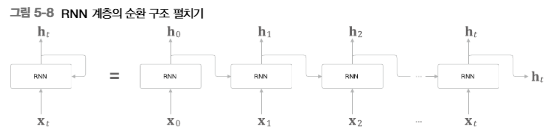   
- 그림에서 보듯, RNN 계층의 순환 구조를 펼침으로써 오른쪽으로 성장하는 긴 신경망으로 변신시킬 수 있음
- 지금까지 본 피드포워드 신경망과 같은 구조(피드포워드에서는 데이터가 한 방향으로만 흐름)
- 다만, 그림에 등장하는 다수의 RNN 계층 모두가 실제로는 '같은 계층'인 것이 지금까지의 신경망과는 다름   

> 시계열 데이터는 시간 방향으로 데이터가 나열됨   
> 따라서 시계열 데이터의 인덱스를 가리킬 때는 '시각'이라는 용어를 사용함(예컨대 시각 t의 입력 데이터 xt 등)   
> 자연어의 경우에도 't번째 단어'나 't번째 RNN 계층'이라는 표현도 사용하지만, '시각 t의 단어'나 '시각 t의 RNN 계층'처럼 표현하기도 함   

그림을 보면 알 수 있듯, 각 시각의 RNN 계층은 그 계층으로의 입력과 1개 전의 RNN 계층으로부터의 출력을 받음   
그리고 이 두 정보를 바탕으로 현 시각의 출력을 계산함   
이때 수행하는 계산의 수식은 다음과 같음   
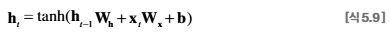   
- 우선 식에 쓰인 기호들을 설명하면
    - RNN에서는 가중치가 2개 있는데 하나는 입력 x를 출력 h로 변환하기 위한 가중치 Wx이고, 다른 하나는 1개의 RNN 출력을 다음 시각의 출력으로 변환하기 위한 가중치 Wh
    - 또한 편향 b도 있음
    - 참고로 ht-1과 xt는 행 벡터
- 식에서는 행렬 곱을 계산하고, 그 합을 tanh 함수(쌍곡탄젠트(hyperbolic tangent) 함수)를 이용해 변환함
- 그 결과가 시각 t의 출력 ht가 됨
- 이 ht는 다른 계층을 향해 위쪽으로 출력되는 동시에, 다음 시각의 RNN 계층(자기 자신)을 향해 오른쪽으로도 출력됨
- 그런데 식을 보면 현재의 출력(ht)은 한 시각 이전 출력(ht-1)에 기초해 계산됨을 알 수 있음
- 다른 관점으로 보면, RNN은 h라는 '상태'를 가지고 있으며, 위 식의 형태로 갱신된다고 해석할 수 있음
- 그래서 RNN 계층을 '상태를 가지는 계층' 혹은 '메모리(기억력)가 있는 계층'이라고 함   

> RNN의 h는 '상태'를 기억해 시각이 1스텝(1단위) 진행될 때마다 위 식의 형태로 갱신됨   
> 많은 문헌에서 RNN의 출력 ht를 **은닉 상태(hidden state)** 혹은 **은닉 상태 벡터(hidden state vector)** 라고 함   
> 이 책에서도 마찬가지로 RNN의 출력 ht를 '은닉 상태' 혹은 '은닉 상태 벡터'로 부름   

또한 많은 문헌에서 펼쳐진 RNN 계층을 아래 그림의 왼쪽처럼 그림   
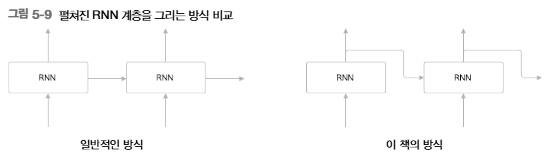   
- 그림의 왼쪽에서는 RNN 계층으로부터 나가는 두 화살표가 똑같은 데이터가 복사돼 분기된다는 사실이 잘 드러나지 않음
- 그래서 이 책에서는 (지금까지처럼) 그림의 오른쪽 그림과 같이 하나의 출력이 분기하는 것임을 명시함

### BPTT

앞에서 봤듯이 RNN 계층은 가로로 펼친 신경망으로 간주할 수 있음   
따라서 RNN의 학습도 보통의 신경망과 같은 순서로 진행할 수 있음   
아래 그림과 같은 모습이 되는 것   
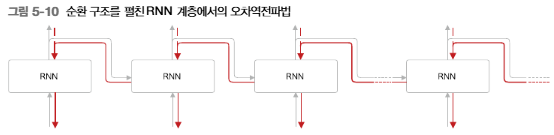   
- 그림에서 보듯, 순환 구조를 펼친 후의 RNN에는 (일반적인) 오차역전파법을 적용할 수 있음
- 즉, 먼저 순전파를 수행하고, 이어서 역전파를 수행하여 원하는 기울기를 구할 수 있음
- 여기서의 오차역전파법은 '시간 방향으로 펼친 신경망의 오차역전파법'이란 뜻으로 **BPTT(Backpropagation Through Time)** 라고 함   

이 BPTT를 이용하면 RNN을 학습할 수 있을 듯 보임   
하지만 그전에 해결해야 할 문제가 하나 있음   
바로 긴 시계열 데이터를 학습할 때의 문제   
이것이 왜 문제가 되는가 하면, 시계열 데이터의 시간 크기가 커지는 것에 비례하여 BPTT가 소비하는 컴퓨팅자원도 증가하기 때문   
또한, 시간 크기가 커지면 역전파 시의 기울기가 불안정해지는 것도 문제   

> BPTT를 이용해 기울기를 구하려면, 매 시각 RNN 계층의 중간 데이터를 메모리에 유지해두지 않으면 안 됨   
> 따라서 시계열 데이터가 길어짐에 따라 (계산량뿐 아니라) 메모리 사용량도 증가하게 됨

### Truncated BPTT

큰 시계열 데이터를 취급할 때는 흔히 신경망 연결을 적당한 길이로 '끊음'   
시간축 방향으로 너무 길어진 신경망을 적당한 지점에서 잘라내어 작은 신경망 여러 개로 만든다는 아이디어   
그리고 이 잘라낸 작은 신경망에서 오차역전파법을 수행   
이것이 바로 **Truncated BPTT** 라는 기법   

> Truncated는 '잘린'이란 뜻   
> 따라서 Truncated BPTT는 적당한 길이로 '잘라낸' 오차역전파법이 되는 것   

Truncated BPTT에서는 신경망의 연결을 끊지만, 제대로 구현하려면 '역전파'의 연결만 끊어야 함   
순전파의 연결은 반드시 그대로 유지해야 함   
즉, 순전파의 흐름은 끊어지지 않고 전파됨   
한편, 역전파의 연결은 적당한 길이로 잘라내, 그 잘라낸 신경망 단위로 학습을 수행함   

그럼 Truncated BPTT를 구체적인 예를 살펴보면   
길이가 1,000인 시계열 데이터가 있다고 가정   
자연어 문제에서라면 단어 1,000개짜리 말뭉치에 해당함   
덧붙여서, 우리가 지금까지 다룬 PTB 데이터셋에서는 여러 문장을 연결한 것을 하나의 큰 시계열 데이터로 취급했음   
여기에서도 마찬가지로 여러 문장을 연결한 것을 하나의 시계열 데이터로 취급함   

그런데 길이가 1,000인 시계열 데이터를 다루면서 RNN 계층을 펼치면 계층이 가로로 1,000개나 늘어선 신경망이 됨   
물론 계층이 아무리 늘어서더라도 오차역전파법으로 기울기를 계산할 수는 있음   
하지만 너무 길면 계산량과 메모리 사용량 등이 문제가 됨   
또한, 계층이 길어짐에 따라 신경망을 하나 통과할 때마다 기울기 값이 조금씩 작아져서, 이전 시각 t까지 역전파되기 전에 0이 되어 소멸할 수도 있음   
바로 이런 이유로 아래 그림처럼 가로로 길게 뻗은 신경망의 역전파에서는 연결을 적당한 길이로 끊을 생각을 한 것   
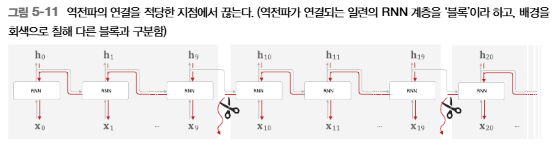   
- 그림에서는 RNN 계층을 길이 10개 단위로 학습할 수 있도록 역전파의 연결을 끊었음
- 이처럼 역전파의 연결을 잘라버리면, 그보다 미래의 데이터에 대해서는 생각할 필요가 없어짐
- 따라서 각각의 블록 단위로, 미래의 블록과는 독립적으로 오차역전파법을 완결시킬 수 있음   

여기서 반드시 기억할 점은 역전파의 연결은 끊어지지만, 순전파의 연결은 끊어지지 않는다는 점   
그러므로 RNN을 학습시킬 때는 순전파가 연결된다는 점을 고려해야 함   
데이터를 '순서대로(sequential)' 입력해야 한다는 뜻   

> 지금까지 본 신경망에서는 미니배치 학습을 수행할 때 데이터를 무작위로 선택해 입력했음   
> 그러나 RNN에서 Truncated BPTT를 수행할 때는 데이터를 '순서대로' 입력해야 함   

이제 Truncated BPTT 방식으로 RNN을 학습시켜보기   
가장 먼저 할 일은 첫 번째 블록 입력 데이터 (x0, ..., x9)를 RNN 계층에 제공하는 것   
그러면 아래 그림과 같은 일이 일어남   
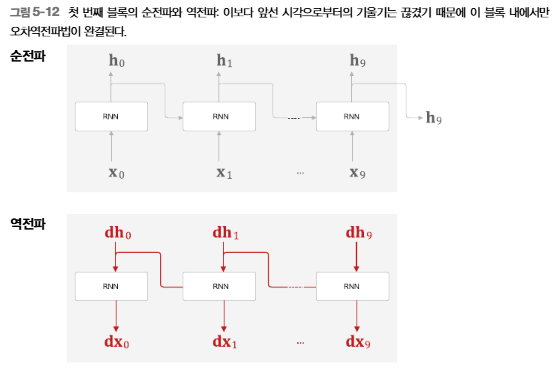   
- 그림에서 보듯, 먼저 순전파를 수행하고, 그다음 역전파를 수행함   
- 이렇게 하여 원하는 기울기를 구할 수 있음
- 이어서 다음 블록의 입력 데이터 (x10 ~ x19)를 입력해 오차역전파법을 수행함
- 그림으로는 다음과 같음   

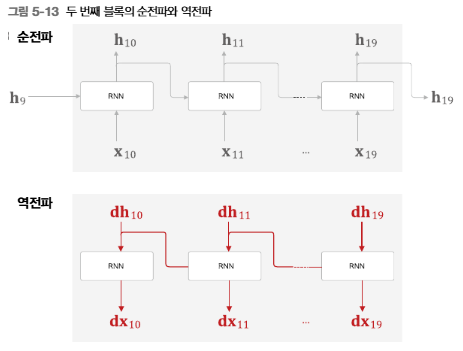   
- 여기에서도 첫 번째 블록과 마찬가지로 순전파를 수행한 다음 역전파를 수행
- 그리고 여기서 중요한 점은 이번 순전파 계산에는 앞 블록의 마지막 은닉 상태인 h9가 필요하다는 것
- 이것으로 순전파는 계속 연결될 수 있음   

같은 요령으로, 이어서 3번째의 블록을 대상으로 학습을 수행함   
이때도 두 번째 블록의 마지막 은닉 상태(h19)를 이용함   
이처럼 RNN 학습에서는 데이터를 순서대로 입력하며, 은닉 상태를 계승하면서 학습을 수행함   
지금까지의 설명으로 RNN 학습의 흐름은 아래 그림처럼 되는 것을 알 수 있음   
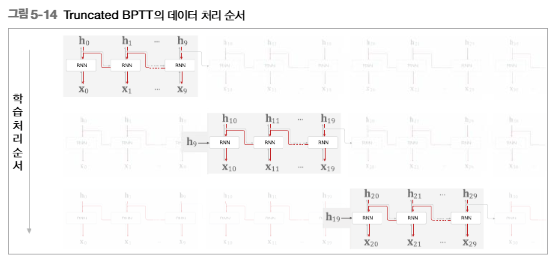   
- 그림처럼 Truncated BPTT에서는 데이터를 순서대로 입력해 학습함
- 이런 식으로 순전파의 연결을 유지하면서 블록 단위로 오차역전파법을 적용할 수 있음

### Truncated BPTT의 미니배치 학습

지금까지의 Truncated BPTT 설명에서는 미니배치 학습 시 각각의 미니배치가 어떤 식으로 이뤄지는지에 대해서는 생각하지 않았음   
굳이 말하자면, 지금까지는 미니배치 수가 1일 때에 해당   
미니배치 학습을 수행해야하기 때문에, 원래대로면 구체적인 배치 방식을 고려해 위에 그림처럼 데이터를 순서대로 입력해야 함   
그렇게 하려면 데이터를 주는 시작 위치를 각 미니배치의 시작 위치로 '옮겨줘야' 함   

'옮긴다'라는 뜻을 설명하기 위해 (앞 절과 마찬가지로) 길이가 1,000인 시계열 데이터에 대해서, 시각의 길이를 10개 단위로 잘라 Truncated BPTT로 학습하는 경우를 예시로   
그러면 이때 미니배치의 수를 두 개로 구성해 학습하려면 어떻게 해야하는지   
이 경우 RNN 계층의 입력 데이터로, 첫 번째 미니배치(샘플 데이터) 때는 처음부터 순서대로 데이터를 제공함   
그리고 두 번째 미니배치 때는 500번째의 데이터를 시작 위치로 정하고, 그 위치부터 다시 순서대로 데이터를 제공하는 것(즉, 시작 위치를 500만큼 '옮겨'줌)   
그림으로는 다음과 같음   
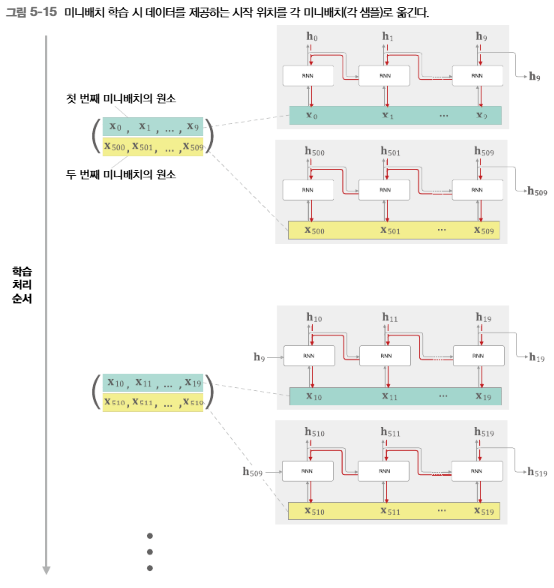   
- 그림처럼 첫 번째 미니배치 원소는 x0, ..., x9가 되고, 두 번째 미니배치 원소는 x500, ..., x509가 됨
- 그리고 이 미니배치 데이터를 RNN의 입력 데이터로 사용해 학습을 수행함
- 이후로는 순서대로 진행되므로 다음에 넘길 데이터는 각각 시계열 데이터의 10~19번째 데이터와 510~519번째의 데이터가 되는 것
- 이처럼 미니배치 학습을 수행할 때는 각 미니배치의 시작 위치를 오프셋으로 옮겨준 후 순서대로 제공하면 됨
- 또한 데이터를 순서대로 입력하다가 끝에 도달하면 다시 처음부터 입력하도록 함   

지금까지 살펴본 것처럼 Truncated BPTT의 원리는 단순하지만, '데이터 제공 방법' 면에서는 몇 가지를 주의해야 함   
구체적으로는 '데이터를 순서대로 제공하기'와 '미니배치별로 데이터를 제공하는 시작 위치를 옮기기'   

## RNN 구현

앞 절까지의 이야기에서 RNN의 전체 모습이 볼 수 있었음   
지금부터 구현해야 할 것은 결국 가로 방향으로 성장한 신경망   
그리고 Truncated BPTT 방식의 학습을 따른다면, 가로 크기가 일정한 일련의 신경망을 만들면 됨   
그림으로는 다음과 같음   
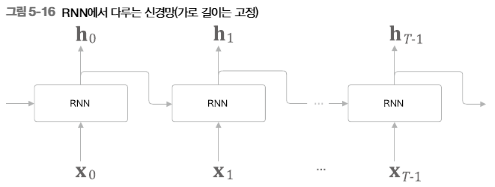   
- 그림에서 보듯, 여기서 다룰 신경망은 길이가 T인 시계열 데이터를 받음(T는 임의 값)
- 그리고 각 시각의 은닉 상태를 T개 출력함
- 그리고 모듈화를 생각해, 옆으로 성장한 이 그림의 신경망을 '하나의 계층'으로 구현함
- 그림으로 보면 다음과 같음   

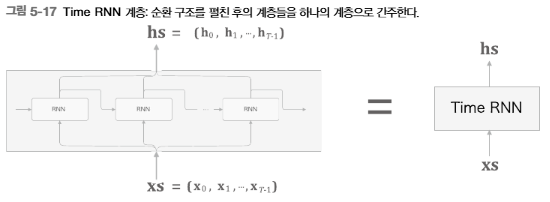   
- 그림과 같이 상하 방향의 입력과 출력을 각각 하나로 묶으면 옆으로 늘어선 일련의 계층을 하나의 계층으로 간주할 수 있음
- 즉,  (x0, x1, ..., xT-1)을 묶은 xs를 입력하면  (h0, h1, ..., hT-1)을 묶은 hs를 출력하는 단일 계층으로 볼 수 있음
- 이때 Time RNN 계층 내에서 한 단계의 작업을 수행하는 계층을 'RNN 계층'이라 하고, T개 단계분의 작업을 한꺼번에 처리하는 계층을 'Time RNN 계층'이라 함   

> Time RNN 같이 시계열 데이터를 한꺼번에 처리하는 계층에는 앞에 'Time'을 붙일 예정 - 이는 이 책 독자적인 명명규칙   
> 나중에 Time Affine 계층과 Time Embedding 계층도 구현하는데, 이것들도 시계열 데이터를 한꺼번에 처리함   

앞으로 할 구현의 흐름은 다음과 같음   
- 먼저 RNN의 한 단계를 처리하는 클래스를 RNN이란 이름으로 구현
- 그리고 이 RNN 클래스를 이용해 T개 단계의 처리를 한꺼번에 수행하는 계층을 TimeRNN이란 이름의 클래스로 완성

### RNN 계층 구현

RNN 처리를 한 단계만 수행하는 RNN 클래스부터 구현해보기   
복습해보자면, RNN의 순전파는 다음 식과 같음   
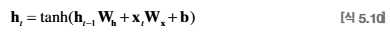   
- 여기에서 데이터를 미니배치로 모아 처리하기로 했음
- 따라서 xt(와 ht)에는 각 샘플 데이터를 행 방향에 저장함
- 한편, 행렬을 계산할 때는 행렬의 '형상 확인'이 중요
- 미니배치 크기가 N, 입력 벡터의 차원 수가 D, 은닉 상태 벡터의 차원 수가 H라면, 지금 계산에서의 형상 확인은 다음과 같이 해볼 수 있음   

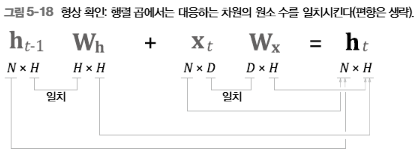   
- 그림에서 보듯, 행렬의 형상 확인을 수행함으로써 올바로 구현되었는지(적어도 계산이 성립하는지)를 확인할 수 있음   

그럼 이상을 바탕으로 RNN 클래스의 초기화와 순전파 메서드를 구현해보면   

In [1]:
import numpy as np

class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = np.dot(h_prev, Wh) + np.dot(x, Wx) + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

- RNN의 초기화 메서드는 가중치 2개와 편향 1개를 인수로 받음
- 여기에서는 인수로 받은 매개변수를 인스턴스 변수 params에 리스트로 저장
- 그리고 각 매개변수에 대응하는 형태로 기울기를 초기화한 후 grads에 저장
- 마지막으로 역전파 계산 시 사용하는 중간 데이터를 담을 cache를 None으로 초기화함
- 순전파인 forward(x, h_prev) 메서드에서는 인수 2개(아래로부터의 입력 x와 왼쪽으로부터의 입력 h_prev)를 받음
- 그다음은 위 식을 그대로 코드로 옮겼을 뿐
- 또한, 하나 앞의 RNN 계층으로부터 받는 입력이 h_prev이고, 현 시각 RNN 계층으로부터의 출력(=다음 시각 계층으로의 입력)은 h_next   

다음은 RNN의 역전파를 구현할 차례   
그전에, RNN의 순전파를 계산 그래프로 다시 한번 확인해보면   
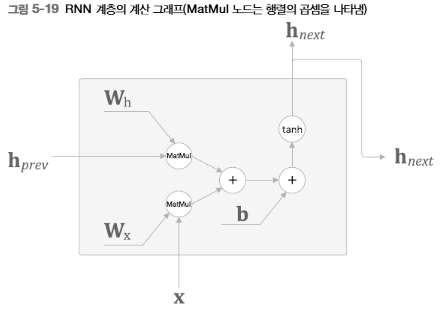   
- 여기에서 수행하는 계산은 행렬의 곱인 'MatMul'과 덧셈인 '+', 그리고 'tanh'라는 3개의 연산으로 구성됨
- 참고로 편향 b의 덧셈에서는 브로드캐스트가 일어나기 때문에 정확하게는 Repeat 노드를 이용하지만, 여기에서는 그림을 간략히 그리고자 일부러 표기하지 않았음   

역전파는 간단히 구할 수 있음   
이미 그 세 가지 연간의 역전파를 공부했기 때문   
다음 그림을 따라서, 순전파 때와는 반대 방향으로 각 연산자의 역전파를 수행하기만 하면 됨   
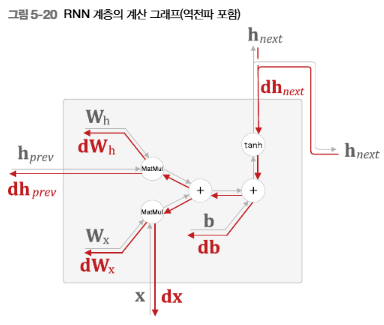   
이제 RNN 계층의 역전파 코드를 구현해보면

In [2]:
def backward(self, dh_next):
    Wx, Wh, b = self.params
    x, h_prev, h_next = self.cache

    dt = dh_next * (1 - h_next ** 2)
    db = np.sum(dt, axis=0)
    dWh = np.dot(h_prev.T, dt)
    dh_prev = np.dot(dt, Wh.T)
    dWx = np.dot(x.T, dt)
    dx = np.dot(dt, Wx.T)

    self.grads[0][...] = dWx
    self.grads[1][...] = dWh
    self.grads[2][...] = db

    return dx, dh_prev

여기까지가 RNN 계층의 구현   
이어서 Time RNN 계층을 구현함

In [3]:
class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = np.dot(h_prev, Wh) + np.dot(x, Wx) + b
        h_next = np.tanh(t)

        self.cache = (x, h_prev, h_next)
        return h_next

    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache

        dt = dh_next * (1 - h_next ** 2)
        db = np.sum(dt, axis=0)
        dWh = np.dot(h_prev.T, dt)
        dh_prev = np.dot(dt, Wh.T)
        dWx = np.dot(x.T, dt)
        dx = np.dot(dt, Wx.T)

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev

### Time RNN 계층 구현

Time RNN 계층은 T개의 RNN 계층으로 구성됨(T는 임의의 수로 설정할 수 있음)   
앞에서도 봤지만, Time RNN 계층은 아래 그림처럼 생겼음   
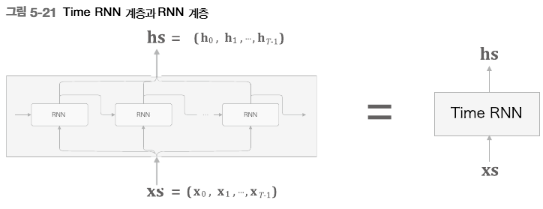   
- 그림에서 보듯,  Time RNN 계층은 RNN 계층 T개를 연결한 신경망
- 이 신경망을 TimeRNN 클래스로 구현할 예정
- 그리고 여기에서는 RNN 계층의 은닉 상태 h를 인스턴스 변수로 유지함
- 이 변수를 아래 그림처럼 은닉 상태를 '인계'받는 용도로 이용함   

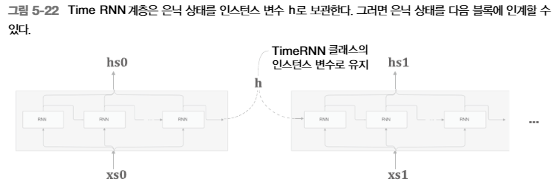   
- 그림처럼 여기선 RNN 계층의 은닉 상태를 Time RNN 계층에서 관리하기로 함
- 이렇게 하면 Time RNN 사용자는 RNN 계층 사이에서 은닉 상태를 '인계하는 작업'을 생각하지 않아도 된다는 장점이 생김
- 그리고 이 책에서는 이 기능(은닉 상태를 인계받을지)을 stateful이라는 인수로 조정할 수 있도록 함   

Time RNN 계층을 구현하기(초기화 메서드와 다른 메서드 2개)

In [4]:
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.dh = None, None
        self.stateful = stateful

    def set_state(self, h):
        self.h = h

    def reset_state(self):
        self.h = None

- 초기화 메서드는 가중치와 편향, stateful이라는 불리언 값(True/False)을 인수로 받음
- 인스턴스 변수 중 layers는 다수의 RNN 계층을 리스트로 저장하는 용도
- 그리고 인스턴스 변수 h는 forward() 메서드를 불렀을 때의 마지막 RNN 계층의 은닉 상태를 저장하고,
- dh는 backward()를 불렀을 때 하나 앞 블록의 은닉 상태의 기울기를 저장함(dh에 관해서는 역전파 구현에서 설명함)   

> TimeRNN 클래스는 확장성을 고려하여 Time RNN 계층의 은닉 상태를 설정하는 메서드를 set_state(h)로,   
> 은닉 상태를 초기화하는 메서드를 reset_state()로 구현했음   

앞의 인수 중 stateful은 '상태가 있는'이란 뜻의 단어   
이 책의 구현에서는 stateful이 True일 때, Time RNN 계층은 '상태가 있다'라고 말함   
여기서 말하는 '상태가 있다'란, Time RNN 계층이 은닉 상태를 유지한다는 뜻   
즉, 아무리 긴 시계열 데이터라도 Time RNN 계층의 순전파를 끊지 않고 전파한다는 의미   
한편, stateful이 False일 때의 Time RNN 계층은 은닉 상태를 '영행렬'(모든 요소가 0인 행렬)로 초기화함   
이것이 상태가 없는 모드이며, '무상태'라고 함   

> 긴 시계열 데이터를 처리할 때는 RNN의 은닉 상태를 유지해야 함   
> 이처럼 은닉 상태를 유지하는 기능을 흔히 'stateful'이라는 단어로 표현함   
> 많은 딥러닝 프레임워크에서 RNN 계층을 살펴보면 인수로 stateful이라는 것을 받으며, 이를 통해 이전 시각의 은닉 상태를 유지할지 지정할 수 있음   

계속해서 순전파를 구현

In [5]:
def forward(self, xs):
    Wx, Wh, b = self.params
    N, T, D = xs.shape
    D, H = Wx.shape

    self.layers = []
    hs = np.empty((N, T, H), dtype='f')

    if not self.stateful or self.h is None:
        self.h = np.zeros((N, H), dtype='f')

    for t in range(T):
        layer = RNN(*self.params)
        self.h = layer.forward(xs[:, t, :], self.h)
        hs[:, t, :] = self.h
        self.layers.append(layer)

    return hs

- 순전파 메서드인 forward(xs)는 아래로부터 입력 xs를 받음
    - xs는 T개 분량의 시계열 데이터를 하나로 모은 것
    - 따라서 미니배치 크기를 N, 입력 벡터의 차원 수를 D라고 하면, xs의 형상은 (N, T, D)가 됨
- RNN 계층의 은닉 상태 h는 처음 호출 시(self.h가 None일 때)에는 원소가 모두 0인 영행렬로 초기화됨
- 그리고 인스턴스 변수 stateful이 False일 때도 항상 영행렬로 초기화함
- 기본 구현에서는 처음 hs = np.empty((N, T, H), dtype='f') 문장에서 출력값을 담을 그릇(hs)을 준비함
- 이어서 총 T회 반복되는 for 문 안에서 RNN 계층을 생성하여 인스턴스 변수 layers에 추가함
- 그 사이에 RNN 계층이 각 시각 t의 은닉 상태 h를 계산하고, 이를 hs에 해당 인덱스(시각)의 값으로 설정함   

> Time RNN 계층의 forward() 메서드가 불리면, 인스턴스 변수 h에는 마지막 RNN 계층의 은닉 상태가 저장됨   
> 그래서 다음번 forward() 메서드 호출 시 stateful이 True면 먼저 저장된 h 값이 그대로 이용되고, stateful이 False면 h가 다시 영행렬로 초기화됨   

이어서 Time RNN 계층의 역전파 구현   
이 역전파의 계산 그래프는 다음과 같음   
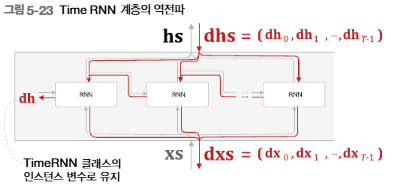   
- 그림과 같이, 여기에서는 상류(출력 쪽 층)에서부터 전해지는 기울기를 dhs로 쓰고, 하류로 내보내는 기울기를 dxs로 씀
- 여기에서 Truncated BPTT를 수행하기 때문에 이 블록의 이전 시각 역전파는 필요하지 않음
- 단, 이전 시각의 은닉 상태 기울기는 인스턴스 변수 dh에 저장해 놓을 것
- 7장에서 다루는 seq2seq(시퀀스 투 시퀀스)에 필요하기 때문, 자세한 내용은 그때 설명한다고 함   

이상이 Time RNN 계층에서 이뤄지는 역전파의 전체 그림   
이때 t번째의 RNN 계층에 주목하면, 그 역전파는 다음처럼 그릴 수 있음   
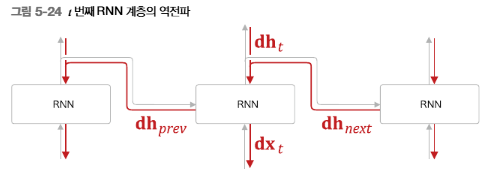   
- t번째 RNN 계층에서는 위로부터의 기울기 dht와 '한 시각 뒤(미래) 계층'으로부터의 기울기 dhnext가 전해짐
- 여기서의 주의점은 RNN 계층의 순전파에서는 출력이 2개로 분기된다는 것
- 순전파 시 분기했을 경우, 그 역전파에서는 각 기울기가 합산되어 전해짐
- 따라서 역전파 시 RNN 계층에는 합산된 기울기(dht + dhnext)가 입력됨   

이상을 주의하여 역전파를 구현하면

In [6]:
def backward(self, dhs):
    Wx, Wh, b = self.params
    N, T, H = dhs.shape
    D, H = Wx.shape

    dxs = np.empty((N, T, D), dtype='f')
    dh = 0
    grads = [0, 0, 0]
    for t in reversed(range(T)):
        layer = self.layers[t]
        dx, dh = layer.backward(dhs[:, t, :] + dh)
        dxs[:, t, :] = dx

        for i, grad in enumerate(layer.grads):
            grads[i] += grad

    for i, grad in enumerate(grads):
        self.grads[i][...] = grad
    self.dh = dh

    return dxs

- 여기에서도 가장 먼저 하류로 흘려보낼 기울기를 담을 그릇인 dxs를 만듦
- 그리고 순전파 때와는 반대 순서로 RNN 계층의 backward() 메서드를 호출하여, 각 시각의 기울기 dx를 구해 dxs의 해당 인덱스(시각)에 저장함
- 그리고 가중치 매개변수에 대해서도 각 RNN 계층의 가중치 기울기를 합산하여 최종 결과를 멤버 변수 self.grads에 덮어씀(이때 ... 문법을 사용함)   

> Time RNN 계층 안에는 RNN 계층이 여러 개 있음   
> 그리고 그 RNN 계층들에서 똑같은 가중치를 사용하고 있음   
> 따라서 Time RNN 계층의 (최종) 가중치의 기울기는 각 RNN 계층의 가중치 기울기를 모두 더한 게 됨

## 시계열 데이터 처리 계층 구현

이번 장의 목표는 RNN을 사용하여 '언어 모델'을 구현하는 것   
지금까지 RNN 계층(과 시계열 데이터를 한꺼번에 처리하는 Time RNN 계층)을 구현했는데, 이번 절에서는 시계열 데이터를 처리하는 계층을 몇 개 더 만들어볼 예정   
또한, RNN을 사용한 언어 모델은 영어로 RNN Language Model이므로 앞으로 RNNLM이라 칭함

### RNNLM의 전체 그림

먼저 RNNLM에서 사용되는 신경망을 한번 보고 시작   
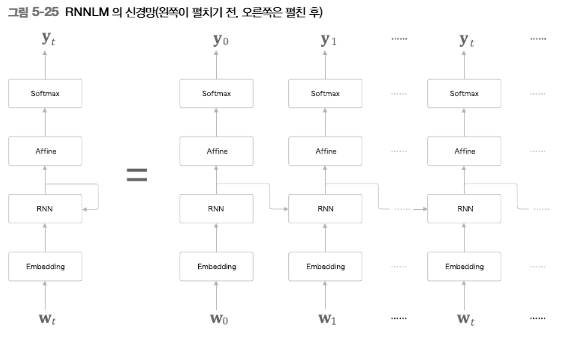   
- 이 그림은 가장 단순한 RNNLM의 신경망을 그려본 것
- 왼쪽은 RNNLM의 계층 구성이고, 오른쪽에는 이를 시간축으로 펼친 신경망
- 그림의 첫 번째(가장 아래) 층은 Embedding 계층
    - 이 계층은 단어 ID를 단어의 분산 표현(단어 벡터)으로 변환함
- 그리고 그 분산 표현이 RNN 계층으로 입력됨
- RNN 계층은 은닉 상태를 다음 층으로(위쪽으로) 출력함과 동시에, 다음 시각의 RNN 계층으로(오른쪽으로) 출력함
- 그리고 RNN 계층이 위로 출력한 은닉 상태는 Affine 계층을 거쳐 Softmax 계층으로 전해짐   

그럼 위 그림의 신경망에서 순전파로 한정해, 구체적인 데이터를 흘려보면서 출력 결과를 관찰해보면   
입력 데이터로는 전에 사용한 문장인 "You say goodbye and I say hello."를 사용함   
이때 RNNLM에서 이뤄지는 처리는 다음과 같음   
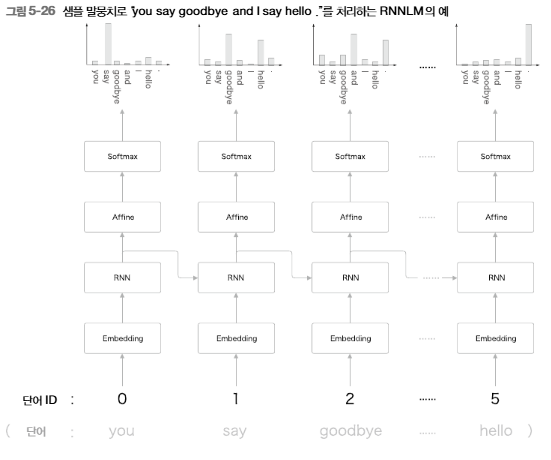   
- 그림에서처럼 입력 데이터는 단어 ID의 배열
- 우선 첫 번째 시각에 주목해보면 여기에서는 첫 단어로 단어 ID가 0인 'you'가 입력됨
    - 이때 Softmax 계층이 출력하는 확률분포를 보면 'say'에서 가장 높게 나온 것을 알 수 있음
    - 다시 말해 'you' 다음에 출현하는 단어가 'say'라는 것을 올바르게 예측했음
    - 당연하지만 이처럼 제대로 예측하려면 좋은 가중치(잘 학습된 가중치)를 사용해야 함
- 이어서 두 번째 단어인 'say'를 입력하는 부분에 주목해보면
    - 이때의 Softmax 계층 출력은 'goodbye'와 'hello', 두 곳에서 높게 나왔음
    - 확실히 "you say goodbye"와 "you say hello"는 모두 자연스러운 문장(참고로 여기에서의 정답은 'goodbye')
- 여기서 주목할 것은 RNN 계층은 "you say"라는 맥락을 '기억'하고 있다는 사실
- 더 정확하게 말하면, RNN은 "you say"라는 과거의 정보를 응집된 은닉 상태 벡터로 저장해두고 있음
- 그러한 정보를 더 위의 Affine 계층에, 그리고 다음 시각의 RNN 계층에 전달하는 것이 RNN 계층이 하는 일   

이처럼 RNNLM은 지금까지 입력된 단어를 '기억'하고, 그것을 바탕으로 다음에 출현할 단어를 예측함   
이 일을 가능하게 하는 비결이 바로 RNN 계층의 존재   
RNN 계층이 과거에서 현재로 데이터를 계속 흘려보내줌으로써 과거의 정보를 인코딩해 저장(기억)할 수 있는 것

### Time 계층 구현

지금까지는 시계열 데이터를 한꺼번에 처리하는 계층을 Time RNN이라는 이름의 계층으로 구현했음   
이번 절에서도 마찬가지로, 시계열 데이터를 한꺼번에 처리하는 계층을 Time Embedding, Time Affine 형태의 이름으로 구현함   
이 Time XX 계층들을 다 만들면 여기서 원하는 신경망을 다음 그림의 형태로 구현할 수 있음   
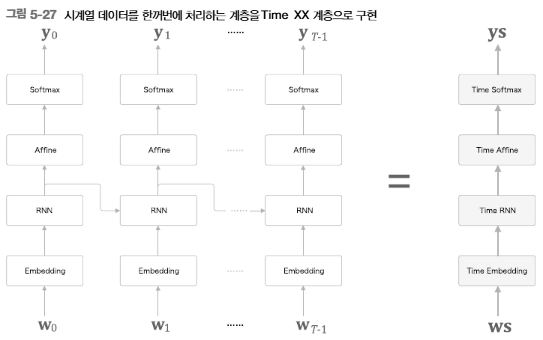   

> T개분의 시계열 데이터를 한꺼번에 처리하는 계층을 'Time XX 계층'이라 부름   
> 이러한 계층들이 구현돼 있다면, 그 계층들을 레고 블록처럼 조립하는 것만으로 시계열 데이터를 다루는 신경망을 완성할 수 있음   

Time 계층은 간단하게 구현할 수 있음   
예컨대 Time Affine 계층은 아래 그림처럼 Affine 계층을 T개 준비해서, 각 시각의 데이터를 개별적으로 처리하면 됨   
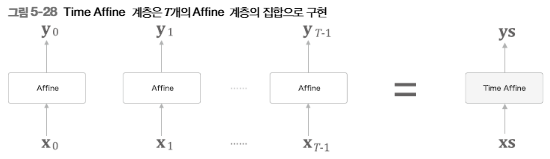   
Time Embedding 계층 역시 순전파 시에 T개의 Embedding 계층을 준비하고 각 Embedding 계층이 각 시각의 데이터를 처리함   

참고로, 이 책에서 Time Affine 계층은 단순히 Affine 계층 T개를 이용하는 방식 대신 행렬 계산으로 한꺼번에 처리하는 효율 좋은 방식으로 구현했음

In [7]:
class TimeAffine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        N, T, D = x.shape
        W, b = self.params

        rx = x.reshape(N*T, -1)
        out = np.dot(rx, W) + b
        self.x = x
        return out.reshape(N, T, -1)

    def backward(self, dout):
        x = self.x
        N, T, D = x.shape
        W, b = self.params

        dout = dout.reshape(N*T, -1)
        rx = x.reshape(N*T, -1)

        db = np.sum(dout, axis=0)
        dW = np.dot(rx.T, dout)
        dx = np.dot(dout, W.T)
        dx = dx.reshape(*x.shape)

        self.grads[0][...] = dW
        self.grads[1][...] = db

        return dx

In [9]:
import sys
sys.path.append('..')
from common.layers import *

class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.W.shape

        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)

        return out

    def backward(self, dout):
        N, T, D = dout.shape

        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

계속해서 시계열 버전의 Softmax를 살펴보기   
Softmax 계층을 구현할 때는 손실 오차를 구하는 Cross Entropy Error 계층도 함께 구현함   
여기에서는 다음 그림과 같은 구성의 Time Softmax with Loss 계층으로 구현할 것   
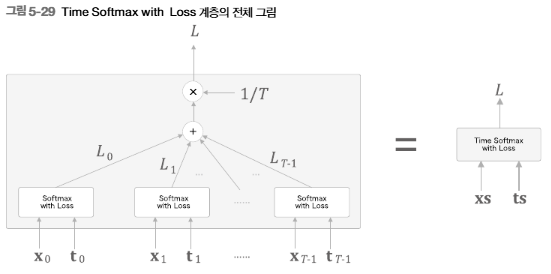   
- 그림에서 x0이나 x1 등의 데이터는 아래층에서부터 전해지는 '점수'를 나타냄(점수란 확률로 정규화되기 전의 값)
- 또한, t0나 t1 등의 데이터는 정답 레이블을 나타냄
- 그림에서 보듯, T개의 Softmax with Loss 계층 각각이 손실을 산출함
- 그리고 그 손실들을 합산해 평균한 값이 최종 손실이 됨
- 이때 수행하는 계산의 수식은 다음과 같음   

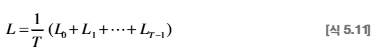   
- 그런데 이 책의 Softmax with Loss 계층은 미니배치에 해당하는 손실의 평균을 구했음
- 다시 말해, 데이터 N개짜리 미니배치라면 그 N개의 손실을 더해 다시 N으로 나눠 데이터 1개당 평균 손실을 구했음
- 이와 마찬가지로 Time Softmax with Loss 계층도 시계열에 대한 평균을 구하는 것으로, 데이터 1개당 평균 손실을 구해 최종 출력으로 내보냄

In [10]:
class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        N, T, V = xs.shape

        if ts.ndim == 3:  # 정답 레이블이 원핫 벡터인 경우
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)

        # 배치용과 시계열용을 정리(reshape)
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        ls = np.log(ys[np.arange(N * T), ts])
        ls *= mask  # ignore_label에 해당하는 데이터는 손실을 0으로 설정
        loss = -np.sum(ls)
        loss /= mask.sum()

        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache

        dx = ys
        dx[np.arange(N * T), ts] -= 1
        dx *= dout
        dx /= mask.sum()
        dx *= mask[:, np.newaxis]  # ignore_label에 해당하는 데이터는 기울기를 0으로 설정

        dx = dx.reshape((N, T, V))

        return dx

## RNNLM 학습과 평가

RNNLM 구현에 필요한 계층은 모두 구현했음   
그러면 RNNLM을 구현하고 실제로 학습시켜보고 그 성능을 평가해볼 차례   

### RNNLM 구현

RNNLM에서 사용하는 신경망을 SimpleRnnlm이라는 이름의 클래스로 구현   
SimpleRnnlm의 계층 구성은 다음과 같음   
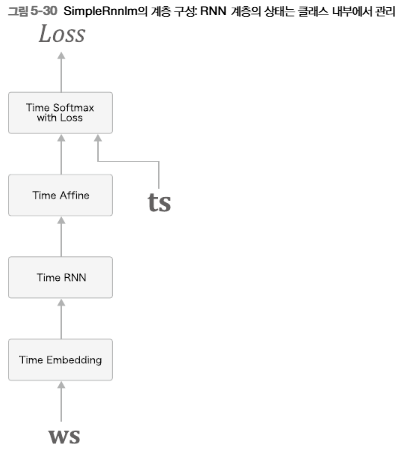   
- 그림과 같이 SimpleRnnlm 클래스는 4개의 Time 계층을 쌓은 신경망   

초기화 코드부터 보면

In [12]:
import sys
sys.path.append('..')
import numpy as np
from common.time_layers import *


class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

- 이 초기화 메서드는 각 계층에서 사용하는 매개변수(가중치와 편향)를 초기화하고 필요한 계층을 생성함
- 또, Truncated BPTT로 학습한다고 가정하여 Time RNN 계층의 stateful을 True로 설정
- 그 결과 Time RNN 계층은 이전 시각의 은닉 상태를 계승할 수 있게 됨
- 또한 RNN 계층과 Affine 계층에서 'Xavier 초깃값(사비에르 초깃값)'을 이용했음
- Xavier 초깃값에서는 이전 계층의 노드가 n개라면 표준편차가 인 분포로 값들을 초기화함(아래 그림)
- 참고로 표준편차는 데이터의 차이를 직관적으로 나타내는 척도로 해석할 수 있음   

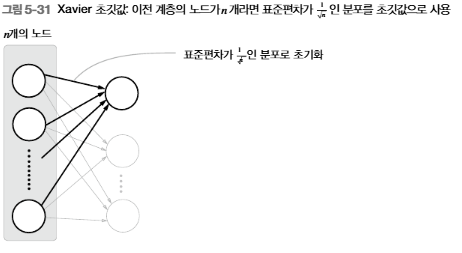   

> 딥러닝에서는 가중치의 초깃값이 중요함   
> 마찬가지로 RNN에서도 가중치의 초깃값은 매우 중요함   
> 초깃값을 어떻게 설정하느냐에 따라 학습이 진행되는 방법과 최종 정확도가 크게 달라짐   
> 이 책에서는 이후로도 가중치의 초깃값으로는 'Xavier 초깃값'을 사용함   
> 또한, 언어 모델을 다루는 연구에서는 0.01 * np.random.uniform(...)처럼 스케일을 변환한 균일분포를 이용하는 사례를 많이 볼 수 있음   

계속해서 forward(), backward(), reset_state() 메서드의 구현

In [13]:
def forward(self, xs, ts):
    for layer in self.layers:
        xs = layer.forward(xs)
    loss = self.loss_layer.forward(xs, ts)
    return loss

def backward(self, dout=1):
    dout = self.loss_layer.backward(dout)
    for layer in reversed(self.layers):
        dout = layer.backward(dout)
    return dout

def reset_state(self):
    self.rnn_layer.reset_state()

- 보다시피 아주 간단함
- 각각의 계층에서 순전파와 역전파를 적절히 구현해뒀으므로, 여기에서는 해당 계층의 forward()(혹은 backward()) 메서드를 적절한 순서로 호출해줬을 뿐
- 마지막 reset_state()는 신경망의 상태를 초기화하는 편의 메서드

In [15]:
class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()

### 언어 모델의 평가

SimpleRnnlm 구현이 끝남   
이제 이 신경망에 데이터를 주고 학습을 수행하는 일만 남음   
학습을 위한 코드를 구현하기에 앞서 언어 모델의 '평가 방법'에 관해 조금 이야기할 예정   

언어 모델은 주어진 과거 단어(정보)로부터 다음에 출현할 단어의 확률분포를 출력함   
이때 언어 모델의 예측 성능을 평가하는 척도로 **퍼플렉서티(perplexity)(혼란도)** 를 자주 이용함   

퍼플렉서티는 간단히 말하면 '확률의 역수'(이 해석은 데이터 수가 하나일 때에 정확히 일치함)   
'확률의 역수'라는 개념을 설명하기 위해 다시 한번 "you say goodbye and I say hello." 말뭉치를 예로 생각해보면   
'모델 1'의 언어 모델에 'you'라는 단어를 주니 아래 그림의 왼쪽과 같은 확률분포를 출력했다고 가정   
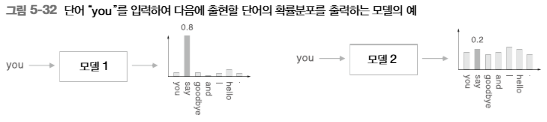   
그리고 정답(다음에 출현할 단어)이 'say'라면, 그 확률은 0.8 - 제법 괜찮은 예측이라고 할 수 있음   
이때의 퍼플렉서티는 이 확률의 역수, 즉 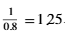로 계산할 수 있음   

한편 그림의 오른쪽 모델('모델 2')은 정답인 'say'의 확률이 0.2라고 예측음 - 분명 나쁜 예측이라고 할 수 있음   
이때의 퍼플렉서티는    

지금까지의 내용을 정리해보면   
'모델 1'은 제법 잘 예측하여 퍼플렉서티가 1.25였음   
한편, '모델 2'의 예측은 좋지 못했고, 그때의 퍼플렉서티는 5.0   
이 예에서 퍼플렉서티는 작을수록 좋다는 것을 알 수 있음   

그렇다면 1.25나 5.0이라는 값은 직관적으로는 어떻게 해석하는지   
이 값은 '분기 수(number of branches)'로 해석할 수 있음   
분기 수란 다음에 취할 수 있는 선택사항의 수(구체적으로 말하면, 다음에 출현할 수 있는 단어의 후보 수)를 말함   
앞의 예에서, 좋은 모델이 예측한 '분기 수'가 1.25라는 것은 다음에 출현할 수 있는 단어의 후보를 1개 정도로 좁혔다는 뜻   
반면 나쁜 모델에서는 후보가 아직 5개나 된다는 의미   

> 앞의 예처럼 퍼플렉서티로 모델의 예측 성능을 평가할 수 있음   
> 좋은 모델은 정답 단어를 높은 확률로 예측할 수 있음   
> 따라서 퍼플렉서티 값이 작음(최솟값은 1.0)   
> 한편, 나쁜 모델은 정답 단어를 낮은 확률로 예측하므로 퍼플렉서티 값이 큼   

지금까지는 입력 데이터가 하나일 때의 퍼플렉서티를 이야기했음   
입력 데이터가 여러 개일 때는 다음 공식에 따라 계산함   
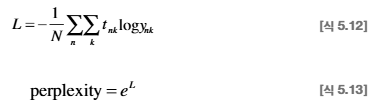   
- N은 데이터의 총개수
- tn은 원핫 벡터로 나타낸 정답 레이블, tnk는 n개째 데이터의 k번째 값을 의미
- 그리고 ynk는 확률분포를 나타냄(신경망에서는 Softmax의 출력)
- L은 신경망의 손실을 뜻하며, 사실 교차 엔트로피 오차를 뜻하는 식과 완전히 같은 식
- 이 L을 사용해 e^L을 계산한 값이 곧 퍼플렉서티   

위의 식 5.12는 다소 복잡해보이지만, 데이터가 하나일 때 설명한 '확률의 역수', '분기 수', '선택사항의 수' 같은 개념이 그대로 적용됨   
즉, 퍼플렉서티가 작아질수록 분기 수가 줄어 좋은 모델이 됨   

> 정보이론 분야에서는 퍼플렉서티를 '기하평균 분기 수'라고도 함   
> 이는 데이터가 1개일 때 설명한 '분기 수'를 데이터가 N개인 경우에서 평균한 것이라고 해석할 수 있음

### RNNLM의 학습 코드

PTB 데이터셋을 이용해 RNNLM 학습을 수행해보기   
단, 이번에 구현할 RNNLM은 PTB 데이터셋(훈련 데이터) 전부를 대상으로 학습하면 전혀 좋은 결과를 낼 수 없기 때문에, 처음 1,000개 단어만 이용할 예정   
이 문제는 다음 장에서 개선함   

학습을 진행하는 코드는

말뭉치 크기: 1000, 어휘 수: 418
| 에폭 1 | 퍼플렉서티 384.64
| 에폭 2 | 퍼플렉서티 252.88
| 에폭 3 | 퍼플렉서티 220.24
| 에폭 4 | 퍼플렉서티 213.71
| 에폭 5 | 퍼플렉서티 204.28
| 에폭 6 | 퍼플렉서티 201.48
| 에폭 7 | 퍼플렉서티 198.00
| 에폭 8 | 퍼플렉서티 195.19
| 에폭 9 | 퍼플렉서티 190.89
| 에폭 10 | 퍼플렉서티 192.19
| 에폭 11 | 퍼플렉서티 188.60
| 에폭 12 | 퍼플렉서티 191.41
| 에폭 13 | 퍼플렉서티 188.89
| 에폭 14 | 퍼플렉서티 189.93
| 에폭 15 | 퍼플렉서티 188.12
| 에폭 16 | 퍼플렉서티 184.86
| 에폭 17 | 퍼플렉서티 183.27
| 에폭 18 | 퍼플렉서티 179.92
| 에폭 19 | 퍼플렉서티 181.82
| 에폭 20 | 퍼플렉서티 183.55
| 에폭 21 | 퍼플렉서티 180.36
| 에폭 22 | 퍼플렉서티 176.40
| 에폭 23 | 퍼플렉서티 175.30
| 에폭 24 | 퍼플렉서티 177.19
| 에폭 25 | 퍼플렉서티 175.35
| 에폭 26 | 퍼플렉서티 173.14
| 에폭 27 | 퍼플렉서티 167.54
| 에폭 28 | 퍼플렉서티 166.58
| 에폭 29 | 퍼플렉서티 166.13
| 에폭 30 | 퍼플렉서티 158.89
| 에폭 31 | 퍼플렉서티 161.63
| 에폭 32 | 퍼플렉서티 157.01
| 에폭 33 | 퍼플렉서티 157.51
| 에폭 34 | 퍼플렉서티 150.99
| 에폭 35 | 퍼플렉서티 151.60
| 에폭 36 | 퍼플렉서티 142.19
| 에폭 37 | 퍼플렉서티 138.46
| 에폭 38 | 퍼플렉서티 137.50
| 에폭 39 | 퍼플렉서티 132.37
| 에폭 40 | 퍼플렉서티 127.77
| 에폭 41 | 퍼플렉서티 128.71
| 에폭 42 | 퍼플렉서티 120.10
| 에폭 43 | 퍼플렉서티 115

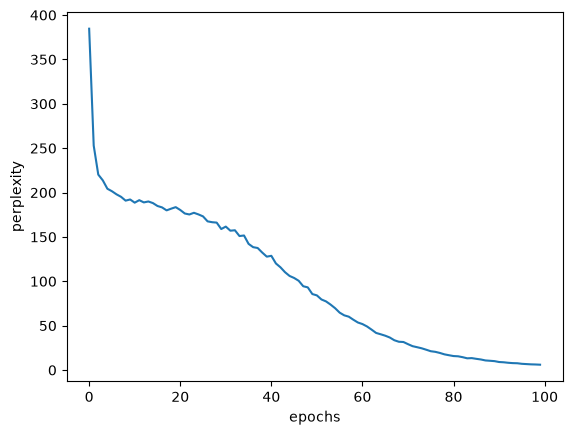

In [ ]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
from common.optimizer import SGD
from dataset import ptb


# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100 # RNN의 은닉 상태 벡터의 원소 수
time_size = 5     # Truncated BPTT가 한 번에 펼치는 시간 크기
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기(전체 중 1000개만)
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # 입력
ts = corpus[1:]   # 출력(정답 레이블)
data_size = len(xs)
print('말뭉치 크기: %d, 어휘 수: %d' % (corpus_size, vocab_size))

# 학습 시 사용하는 변수
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# 1. 미니배치의 각 샘플의 읽기 시작 위치를 계산
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # 2. 미니배치 취득
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        # 기울기를 구하여 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # 3. 에폭마다 퍼플렉서티 평가
    ppl = np.exp(total_loss / loss_count)
    print('| 에폭 %d | 퍼플렉서티 %.2f'
          % (epoch+1, ppl))
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0

# 그래프 그리기
x = np.arange(len(ppl_list))
plt.plot(x, ppl_list, label='train')
plt.xlabel('epochs')
plt.ylabel('perplexity')
plt.show()

- 기본적으로는 지금까지 본 신경망 학습과 거의 같음
- 다만, 큰 관점에서 두 가지가 지금까지의 학습 코드와 다름 - '데이터 제공 방법'과 '퍼플렉서티 계산' 부분
- 우선 '데이터 제공 방법'에 대해서
    - 여기서 Truncated BPTT 방식으로 학습을 수행함
    - 따라서 데이터는 순차적으로 주고 각각의 미니배치에서 데이터를 읽는 시작 위치를 조정해야 함
    - 코드의 1. 에서는 각 미니배치가 데이터를 읽기 시작하는 위치를 계산해 offsets에 저장함
    - 다시 말해 이 offsets의 각 원소에 데이터를 읽는 시작 위치(오프셋)가 담기게 됨
    - 이어서 코드의 2. 에서는 데이터를 순차적으로 읽음
    - 먼저 '그릇'인 batch_x와 batch_t를 준비함
    - 그런 다음 변수 time_idx를 1씩(순차적으로) 늘리면서, 말뭉치에서 time_idx 위치의 데이터를 얻음
    - 여기서 1. 에서 계산한 offsets를 이용하여 각 미니배치에서 오프셋을 추가함
    - 또한, 말뭉치를 읽는 위치가 말뭉치 크기를 넘어설 경우 말뭉치의 처음으로 돌아와야 하는데, 이를 위해 말뭉치의 크기로 나눈 나머지를 인덱스로 사용함
- 마지막으로 위에 식를 따라 퍼플렉서티를 계산함 - 코드의 3. 부분
    - 여기에서는 에폭마다의 퍼플렉서티를 구하기 위해 에폭마다 손실의 평균을 구하고, 그 값을 사용해 퍼플렉서티를 구함   
    
그럼 이제 학습 결과를 살펴보면   
앞의 코드에서 에폭별 퍼플렉서티 결과를 perplexity_list에 저장했으므로, 이 리스트를 플롯하면 아래 그림의 그래프를 얻을 수 있음   
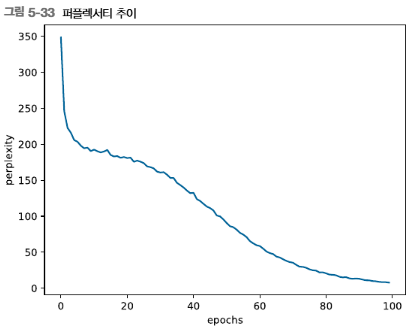   
- 그림을 보면 학습을 진행할수록 퍼플렉서티가 순조롭게 낮아짐을 알 수 있음
- 처음에는 300을 넘던 값이 마지막에는 (최솟값인) 1에 근접했음
- 다만, 이번에는 크기가 작은 말뭉치로 실험한 것
- 실제로 현재의 모델로는 큰 말뭉치에는 전혀 대응할 수 없음
- 현재 RNNLM의 이런 문제는 다음 장에서 개선

### RNNLM의 Trainer 클래스

이 책에서는 RNNLM 학습을 수행해주는 RnnlmTrainer 클래스를 제공함   
이 클래스는 방금 수행한 RNNLM 학습을 클래스 안으로 숨겨줌   

In [19]:
import sys
sys.path.append('..')
import numpy
import time
import matplotlib.pyplot as plt
import numpy as np
from common.util import clip_grads

def remove_duplicate(params, grads):
    '''
    매개변수 배열 중 중복되는 가중치를 하나로 모아
    그 가중치에 대응하는 기울기를 더함
    '''
    params, grads = params[:], grads[:]  # copy list

    while True:
        find_flg = False
        L = len(params)

        for i in range(0, L - 1):
            for j in range(i + 1, L):
                # 가중치 공유 시
                if params[i] is params[j]:
                    grads[i] += grads[j]  # 경사를 더함
                    find_flg = True
                    params.pop(j)
                    grads.pop(j)
                # 가중치를 전치행렬로 공유하는 경우(weight tying)
                elif params[i].ndim == 2 and params[j].ndim == 2 and \
                     params[i].T.shape == params[j].shape and np.all(params[i].T == params[j]):
                    grads[i] += grads[j].T
                    find_flg = True
                    params.pop(j)
                    grads.pop(j)

                if find_flg: break
            if find_flg: break

        if not find_flg: break

    return params, grads

class RnnlmTrainer:
    def __init__(self, model, optimizer):
        self.model = model
        self.optimizer = optimizer
        self.time_idx = None
        self.ppl_list = None
        self.eval_interval = None
        self.current_epoch = 0

    def get_batch(self, x, t, batch_size, time_size):
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')

        data_size = len(x)
        jump = data_size // batch_size
        offsets = [i * jump for i in range(batch_size)]  # 배치에서 각 샘플을 읽기 시작하는 위치

        for time in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, time] = x[(offset + self.time_idx) % data_size]
                batch_t[i, time] = t[(offset + self.time_idx) % data_size]
            self.time_idx += 1
        return batch_x, batch_t

    def fit(self, xs, ts, max_epoch=10, batch_size=20, time_size=35,
            max_grad=None, eval_interval=20):
        data_size = len(xs)
        max_iters = data_size // (batch_size * time_size)
        self.time_idx = 0
        self.ppl_list = []
        self.eval_interval = eval_interval
        model, optimizer = self.model, self.optimizer
        total_loss = 0
        loss_count = 0

        start_time = time.time()
        for epoch in range(max_epoch):
            for iters in range(max_iters):
                batch_x, batch_t = self.get_batch(xs, ts, batch_size, time_size)

                # 기울기를 구해 매개변수 갱신
                loss = model.forward(batch_x, batch_t)
                model.backward()
                params, grads = remove_duplicate(model.params, model.grads)  # 공유된 가중치를 하나로 모음
                if max_grad is not None:
                    clip_grads(grads, max_grad)
                optimizer.update(params, grads)
                total_loss += loss
                loss_count += 1

                # 퍼플렉서티 평가
                if (eval_interval is not None) and (iters % eval_interval) == 0:
                    ppl = np.exp(total_loss / loss_count)
                    elapsed_time = time.time() - start_time
                    print('| 에폭 %d |  반복 %d / %d | 시간 %d[s] | 퍼플렉서티 %.2f'
                          % (self.current_epoch + 1, iters + 1, max_iters, elapsed_time, ppl))
                    self.ppl_list.append(float(ppl))
                    total_loss, loss_count = 0, 0

            self.current_epoch += 1

    def plot(self, ylim=None):
        x = numpy.arange(len(self.ppl_list))
        if ylim is not None:
            plt.ylim(*ylim)
        plt.plot(x, self.ppl_list, label='train')
        plt.xlabel('반복 (x' + str(self.eval_interval) + ')')
        plt.ylabel('퍼플렉서티')
        plt.show()

그래서 앞 절의 학습 코드를 RnnlmTrainer 클래스를 사용해 다시 쓰면 다음과 같이 됨

| 에폭 1 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 418.76
| 에폭 2 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 386.32
| 에폭 3 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 274.63
| 에폭 4 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 227.05
| 에폭 5 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 213.17
| 에폭 6 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 209.80
| 에폭 7 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 202.06
| 에폭 8 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 201.09
| 에폭 9 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 195.06
| 에폭 10 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 190.94
| 에폭 11 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 191.85
| 에폭 12 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 189.22
| 에폭 13 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 192.30
| 에폭 14 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 186.65
| 에폭 15 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 185.93
| 에폭 16 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 189.96
| 에폭 17 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 188.63
| 에폭 18 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 184.19
| 에폭 19 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 180.38
| 에폭 20 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 182.42
| 에폭 21 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 178.96
| 에폭 22 |  반복 1 / 19 | 시간 0[s] | 퍼플렉서티 178.

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47113 (\N{HANGUL 

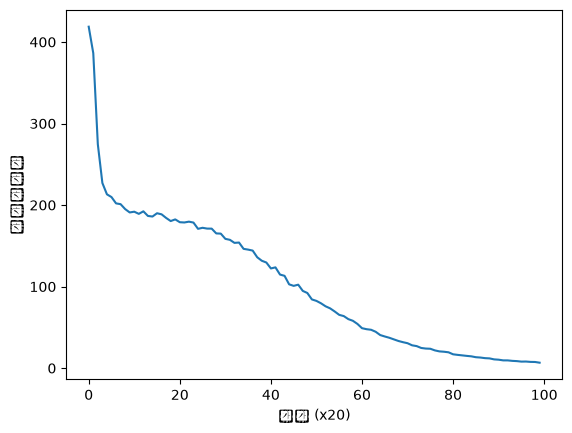

In [20]:
import sys
sys.path.append('..')
from common.optimizer import SGD
from dataset import ptb


# 하이퍼파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100  # RNN의 은닉 상태 벡터의 원소 수
time_size = 5  # RNN을 펼치는 크기
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000  # 테스트 데이터셋을 작게 설정
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)
xs = corpus[:-1]  # 입력
ts = corpus[1:]  # 출력（정답 레이블）

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

trainer.fit(xs, ts, max_epoch, batch_size, time_size)
trainer.plot()

- 먼저 RnnlmTrainer 클래스에 model과 optimizer를 주어 초기화함
- 그런 다음 fit() 메서드를 호출해 학습을 수행함
- 이때 그 내부에서는 앞 절에서 수행한 일련의 작업이 진행되는데, 그 내용을 상세히 적어보면 다음과 같음
    1. 미니배치를 '순차적'으로 만들어
    2. 모델의 순전파와 역전파를 호출하고
    3. 옵티마이저로 가중치를 갱신하고
    4. 퍼플렉서티를 구함

> RnnlmTrainer 클래스는 '1.4.4 Trainer 클래스' 절에서 설명한 Trainer 클래스와 똑같은 API를 제공함   
> 신경망의 일반적인 학습은 Trainer 클래스를 사용하고, RNNLM 학습에는 RnnlmTrainer 클래스를 사용하면 됨   

RnnlmTrainer 클래스를 사용하면 똑같은 코드를 매번 작성하지 않아도 됨   
이 책에서는 앞으로 RNNLM 학습에는 RnnlmTrainer 클래스를 사용함

## 정리

이번 장의 주제는 순환 신경망(RNN)   
RNN은 데이터를 순환시킴으로써 과거에서 현재, 그리고 미래로 데이터를 계속해서 흘려보냄   
이를 위해 RNN 계층 내부에는 '은닉 상태'를 기억하는 능력이 추가됐음   
이번 장에서는 RNN 계층의 구조를 설명하고, 실제로 RNN 계층(그리고 Time RNN 계층)을 구현해봤음   

또한 RNN을 이용해 언어 모델을 만들었음   
언어 모델은 단어 시퀀스에 확률을 부여하며, 특히 조건부 언어 모델은 지금까지의 단어 시퀀스로부터 다음에 출현할 단어의 확률을 계산해줌   
여기서 RNN을 이용한 신경망 구성이 등장하며, 이론적으로는 아무리 긴 시계열 데이터라도 중요 정보를 RNN의 은닉 상태에 기억해둘 수 있음   
그러나 실제 문제에서는 잘 학습하지 못하는 경우가 많음   
다음 장에서는 RNN의 문제점을 살펴보고 RNN을 대체하는 새로운 계층들(LSTM 계층과 GRU 계층)을 살펴봄   
이 새로운 계층들은 실제로 최첨단 연구에서도 많이 이용되는, 시계열 데이터 처리에 있어서 가장 중요한 계층에 속함

### 이번 장에서 배운 내용

- RNN은 순환하는 경로가 있고, 이를 통해 내부에 '은닉 상태'를 기억할 수 있음
- RNN의 순환 경로를 펼침으로써 다수의 RNN 계층이 연결된 신경망으로 해석할 수 있으며, 보통의 오차역전파법으로 학습할 수 있음(=BPTT)
- 긴 시계열 데이터를 학습할 때는 데이터를 적당한 길이씩 모으고(이를 '블록'이라 함), 블록 단위로 BPTT에 의한 학습을 수행함(=Truncated BPTT)
- Truncated BPTT에서는 역전파의 연결만 끊음
- Truncated BPTT에서는 순전파의 연결을 유지하기 위해 데이터를 '순차적'으로 입력해야 함
- 언어 모델은 단어 시퀀스를 확률로 해석함
- RNN 계층을 이용한 조건부 언어 모델은 (이론적으로는) 그때까지 등장한 모든 단어의 정보를 기억할 수 있음